# Thermal Simulator Development

## Objective
Develop a first-order thermal simulator of the building using parameters derived from empirical observations.

The simulator aims to reproduce indoor temperature dynamics based on:
- outdoor temperature
- estimated thermal loss behavior

## Target
The target is to implement a first usable digital twin that can later support prediction, scenario analysis, and control-oriented applications.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
# Load sample data
DATA_PATH = "../data/sample/PreliminaryAnalysis.csv"
df_raw = pd.read_csv(DATA_PATH)

In [3]:
# Import dataset from csv 
min_date = pd.to_datetime('2026-02-25 00:00:00')
max_date = pd.to_datetime('2026-03-02 23:00:00')
df_raw['time'] = pd.to_datetime(df_raw['time'])
df_filtered = df_raw.loc[(df_raw['time'] >= min_date) & (df_raw['time'] <= max_date)]
df_filtered = df_filtered.set_index("time")

## Results on Estimated Cooling Rate based on First Order Model

**Living Room**
- Mean: 
    - k = 0.01150 1/h
    - τ = 88.9 h
    - ΔT ≈ 9°C
    - dT/dt ≈ -0.104 °C/h

**Bedroom**
- Mean: 
    - k = 0.01027 1/h
    - τ = 100.5 h
    - ΔT ≈ 9.4°C
    - dT/dt ≈ -0.097 °C/h

In [4]:
# Parameters definition
column_in = "temp_salon_c"
column_out = "temp_out_1_b_c"
k = 0.011497 # as found in parameters_indentification
dt = 1.0 # hours

# Initial Time window selection
df_sim = df_filtered.loc[min_date:max_date, [column_in, column_out]].dropna().copy()

## Model Development
The following sections progressively extend the thermal simulator from a simple first-order model to more expressive variants.

## Thermal Simulator v1
$T_{t+1} = T_t + (-k (T_t - T_{out})) \Delta t$

In [5]:
def simulate_first_order(T0, Tout_series, k, dt=1.0):
    """
    T_{t+1} = T_t + (-k * (T_t - T_out)) * dt
    """
    Tsim = np.zeros(len(Tout_series), dtype=float)
    Tsim[0] = T0

    for i in range(1, len(Tout_series)):
        T_prev = Tsim[i-1]
        Tout = Tout_series.iloc[i-1]
        Tsim[i] = T_prev + (-k * (T_prev - Tout)) * dt

    return pd.Series(Tsim, index=Tout_series.index, name="Tsim")

### Run Simulation
Initial condition -> first measured value

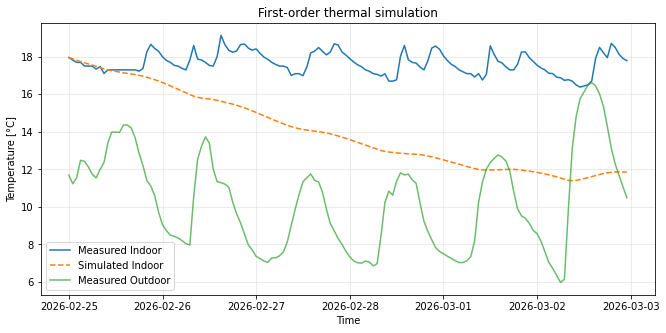

In [6]:
T0 = df_sim[column_in].iloc[0]
df_sim['Tsim_v1'] = simulate_first_order(T0, df_sim[column_out], k)

plt.figure(figsize=(11, 5))
plt.plot(df_sim.index, df_sim[column_in], label="Measured Indoor")
plt.plot(df_sim.index, df_sim["Tsim_v1"], label="Simulated Indoor", linestyle="--")
plt.plot(df_sim.index, df_sim[column_out], label="Measured Outdoor", alpha=0.7)

plt.title("First-order thermal simulation")
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("../reports/figures/03_thermal_simulator/v1_baseline.png", dpi=300, facecolor='white')

plt.show()

The baseline model captures the general cooling trend but fails to reproduce daytime temperature increases, indicating missing heat gain mechanisms.

## Baseline Model Performance

The first-order baseline model captures the expected nighttime cooling behavior reasonably well, but it systematically underestimates indoor temperatures during daytime.

This suggests that heat exchange with the outdoor environment alone is not sufficient to explain the observed dynamics. Additional contributions, such as solar gains and internal heat gains, must be considered.

## v1 - Results

Outdoor temperature (green line) rises during the day.
Measured indoor temperature (blue line) rises significantly more than can be explained by outdoor temperature alone.

This probably means: **solar gain and/or internal gain (HVAC)**

In [7]:
# Function to calculate metrics
def compute_metrics(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return mae, rmse

In [8]:
mae_v1, rmse_v1 = compute_metrics(df_sim[column_in], df_sim['Tsim_v1'])
print(f"V1 MAE  = {mae_v1:.3f} °C | V1 RMSE  = {rmse_v1:.3f} °C")

V1 MAE  = 3.666 °C | V1 RMSE  = 4.170 °C


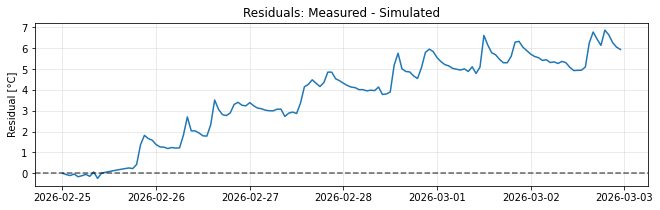

In [9]:
# Plot residuals
df_sim["residual"] = df_sim[column_in] - df_sim["Tsim_v1"]

plt.figure(figsize=(11, 3))
plt.plot(df_sim.index, df_sim["residual"])
plt.axhline(0, color="k", linestyle="--", alpha=0.6)
plt.title("Residuals: Measured - Simulated")
plt.ylabel("Residual [°C]")
plt.grid(True, alpha=0.3)

plt.savefig("../reports/figures/03_thermal_simulator/v1_residuals.png", dpi=300, facecolor='white')

plt.show()

### Interpretation

The residual plot confirms the limitation of the baseline model:

- during nighttime, residuals remain relatively small
- during daytime, residuals become systematically positive

This indicates that the measured indoor temperature is consistently higher than the simulated one, which is compatible with missing daytime heat gains.

## Simulator v2: Constant Daytime Gain

To improve the baseline model, a simple daytime gain term is introduced.

This additional term acts as a coarse proxy for solar and/or internal heat gains during daytime hours. Although simplified, it provides a first way to capture the observed warming pattern that is missing from the baseline model.

$T_{t+1} =T_t + (−k(T_t − T_{out})+ g I_{day}(t)) \Delta t $
* $I_{day}(t) = 1$ if time in range 09:00–16:00
* 0 otherwise
* g in $^oC/h$

g can be estimated by trial-and-error at first.

Simulator v2 will be tested during more days

In [10]:
# Simulator function V2
def simulate_first_order_with_solar(T0, Tout_series, k, dt=1.0, solar_gain=0.2, solar_start="10:00", solar_end="18:00"):
    """
    T_{t+1} = T_t + (-k * (T_t - T_out) + g * I_day) * dt
    """
    Tsim = np.zeros(len(Tout_series), dtype=float)
    Tsim[0] = T0

    # day indicator
    idx = Tout_series.index
    day_mask = ((idx.time >= pd.to_datetime(solar_start).time()) & (idx.time <= pd.to_datetime(solar_end).time())).astype(float)

    for i in range(1, len(Tout_series)):
        T_prev = Tsim[i-1]
        Tout = Tout_series.iloc[i-1]
        solar_term = solar_gain * day_mask[i-1]
        Tsim[i] = T_prev + (-k * (T_prev - Tout) + solar_term) * dt

    return pd.Series(Tsim, index=Tout_series.index, name="Tsim")

In [11]:
df_sim = df_filtered.dropna().copy()
df_sim["Tsim_v2"] = simulate_first_order_with_solar(
    T0,
    df_filtered[column_out],
    k=k,
    dt=dt,
    solar_gain=0.20,      
    solar_start="10:00",
    solar_end="18:00"
)

In [12]:
mae_v2, rmse_v2 = compute_metrics(df_sim[column_in], df_sim["Tsim_v2"])
print(f"V2 MAE: {mae_v2:.3f} °C | RMSE: {rmse_v2:.3f} °C")

V2 MAE: 0.566 °C | RMSE: 0.696 °C


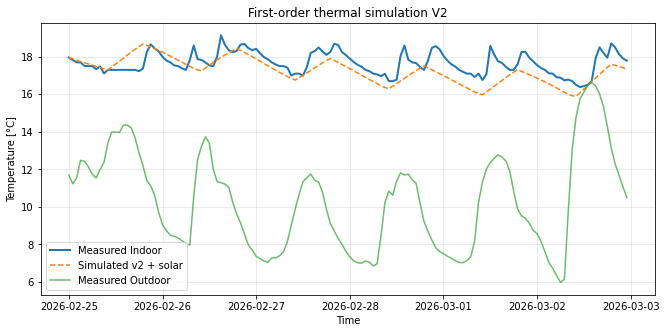

In [13]:
plt.figure(figsize=(11, 5))
plt.plot(df_sim.index, df_sim[column_in], label="Measured Indoor", linewidth=2)
plt.plot(df_sim.index, df_sim["Tsim_v2"], label="Simulated v2 + solar", linestyle="--")
plt.plot(df_sim.index, df_sim[column_out], label="Measured Outdoor", alpha=0.7)
    
plt.title("First-order thermal simulation V2")
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("../reports/figures/03_thermal_simulator/v2_improvement.png", dpi=300, facecolor='white')

plt.show()

Introducing a simple daytime gain term significantly improves the model’s ability to follow measured indoor temperature.

## v2 - Results

The improved performance suggests that the previously estimated **k** value is physically meaningful and can serve as a reasonable starting point for dynamic simulation.

## Simulator v3: Dynamic Solar Proxy

A constant daytime gain improves the model, but it remains too simplistic.

To better represent actual thermal behavior, the gain term is replaced by a dynamic proxy based on the temperature difference between south- and north-facing outdoor sensors. This provides a simple data-driven approximation of solar exposure intensity.

So let's define gain term **g** as:

$g(t) = \alpha \cdot max(T_{out, south}(t) - T_{out, north}(t), 0)$

and the equation of the model (V3) now becomes:

$T_{t+1} = T_t + [-k(T_t - T_{out, north}) + \alpha \cdot max(T_{out, south}(t) - T_{out, north}(t), 0)] \Delta t$

$\alpha$ means:
* gain scaling factor
* turns outdoor difference North-South to "effective heating input" for the northern room

In [14]:
def simulate_first_order_with_dynamic_solar(
    T0, 
    Tout_local_series,
    Tout_north_series,
    Tout_south_series,
    k,
    alpha,
    dt=1.0
):
    """
    First-order thermal model with dynamic solar proxy:
    
    T_{t+1} = T_t + [-k*(T_t - T_out_ref) + alpha * max(T_out_south - T_out_north, 0)] * dt
    
    Parameters
    ----------
    T0 : float
        Initial indoor temperature
    Tout_local_series : pd.Series
        Outdoor reference temperature for the room (e.g. north outdoor for north room)
    Tout_north_series : pd.Series
        North outdoor temperature
    Tout_south_series : pd.Series
        South outdoor temperature
    k : float
        Heat loss coefficient [1/h]
    alpha : float
        Dynamic solar gain scaling factor
    dt : float
        Time step in hours
    """
    idx =Tout_local_series.index
    Tsim = np.zeros(len(idx), dtype=float)
    Tsim[0] = T0

    solar_proxy = np.maximum((Tout_south_series - Tout_north_series).to_numpy(dtype=float), 0.0)

    for i in range(1, len(idx)):
        T_prev = Tsim[i - 1]
        T_out_ref = float(Tout_local_series.iloc[i - 1])
        solar_term = alpha * solar_proxy[i - 1]

        Tsim[i] = T_prev + (-k * (T_prev - T_out_ref) + solar_term) * dt
    return pd.Series(Tsim, index=idx, name="Tsim_v3")

In [15]:
column_in = "temp_salon_c"
column_out_north = "temp_out_1_b_c"
column_out_south = "temp_out_2_n_c"

In [16]:
df_sim = df_filtered.loc[min_date:max_date, [
    column_in,
    column_out_north,
    column_out_south
]].dropna().copy()

T0 = df_sim[column_in].iloc[0]

df_sim["Tsim_v3"] = simulate_first_order_with_dynamic_solar(
    T0=T0,
    Tout_local_series=df_sim[column_out_north],
    Tout_north_series=df_sim[column_out_north],
    Tout_south_series=df_sim[column_out_south],
    k=k,
    alpha=0.058,  
    dt=dt
)

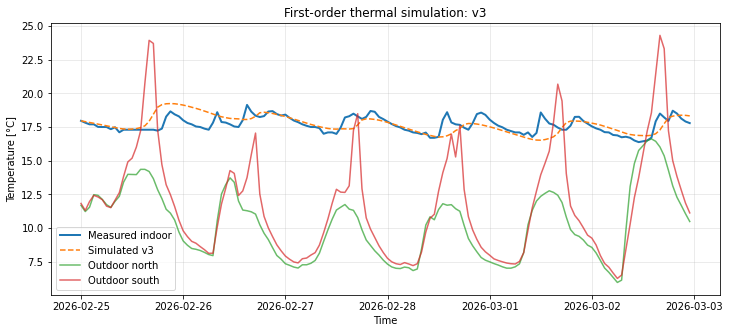

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(df_sim.index, df_sim[column_in], label="Measured indoor", linewidth=2)
plt.plot(df_sim.index, df_sim["Tsim_v3"], label="Simulated v3", linestyle="--")
plt.plot(df_sim.index, df_sim[column_out_north], label="Outdoor north", alpha=0.7)
plt.plot(df_sim.index, df_sim[column_out_south], label="Outdoor south", alpha=0.7)

plt.title("First-order thermal simulation: v3")
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("../reports/figures/03_thermal_simulator/v3_best_model.png", dpi=300, facecolor='white')

plt.show()

Using a dynamic solar proxy further improves the model by adapting to varying external conditions, providing the best overall performance.

In [18]:
mae_v3, rmse_v3 = compute_metrics(df_sim[column_in], df_sim["Tsim_v3"])

print(f"V3 MAE: {mae_v3:.3f} °C | RMSE: {rmse_v3:.3f} °C")

V3 MAE: 0.439 °C | RMSE: 0.614 °C


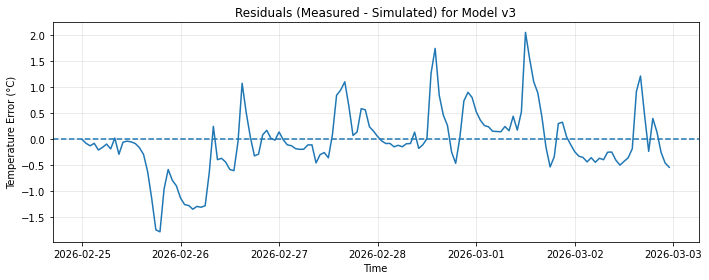

In [19]:
residuals_v3 = df_sim[column_in] - df_sim["Tsim_v3"]

plt.figure(figsize=(10,4))
plt.plot(residuals_v3.index, residuals_v3)
plt.axhline(0, linestyle='--')
plt.title("Residuals (Measured - Simulated) for Model v3")
plt.ylabel("Temperature Error (°C)")
plt.xlabel("Time")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("../reports/figures/03_thermal_simulator/v3_residuals.png", dpi=300, facecolor='white')

Residual analysis confirms that the selected model captures the dominant dynamics, with errors remaining relatively small and centered around zero.

## v3 Results

The dynamic solar proxy further improves the realism of the simulator.

Compared to v2, this version captures daytime temperature rises in a more natural and adaptive way, reflecting variations in solar exposure rather than applying a fixed daytime forcing term.

At this stage, the model provides the best balance between simplicity, interpretability, and predictive accuracy.

## Simulator v4: Memory-Enhanced Solar Proxy

A final model extension is explored by adding a memory term to the solar proxy.

The idea is to account for delayed thermal response and short-term heat storage effects, allowing daytime solar influence to persist over time instead of acting instantaneously only.

In [20]:
def simulate_first_order_with_memory_solar(
    T0,
    Tout_local_series,
    k,
    alpha,
    beta=0.85,
    dt=1.0
):
    """
    First-order thermal model with causal outdoor-warming proxy + memory term.

    T_{t+1} = T_t + [-k*(T_t - T_out) + alpha*S_t] * dt
    S_t = beta*S_{t-1} + max(dT_out/dt, 0)
    """

    idx = Tout_local_series.index
    Tsim = np.zeros(len(idx), dtype=float)
    S = np.zeros(len(idx), dtype=float)
    
    Tsim[0] = T0
    S[0] = 0.0

    Tout = Tout_local_series.to_numpy(dtype=float)

    for i in range(1, len(idx)):
        # causal warming proxy from past step
        dTout_dt = (Tout[i-1] - Tout[i - 2]) / dt if i >= 2 else 0.0
        warming_proxy = max(dTout_dt, 0.0)
        
        # memory state
        S[i] = beta * S[i - 1] + warming_proxy
        
        T_prev = Tsim[i - 1]
        T_out_ref = Tout[i - 1]
        
        Tsim[i] = T_prev + (-k * (T_prev - T_out_ref) + alpha * S[i]) * dt

    return (pd.Series(Tsim, index=idx, name="Tsim_v4b"),
           pd.Series(S, index=idx, name="solar_memory_state")
    )

In [21]:
T0 = df_sim[column_in].iloc[0]

df_sim["Tsim_v4"], df_sim["solar_state"] = simulate_first_order_with_memory_solar(
    T0=T0,
    Tout_local_series=df_sim[column_out],
    k=k,
    alpha=0.068, 
    beta=0.85,  
    dt=dt
)

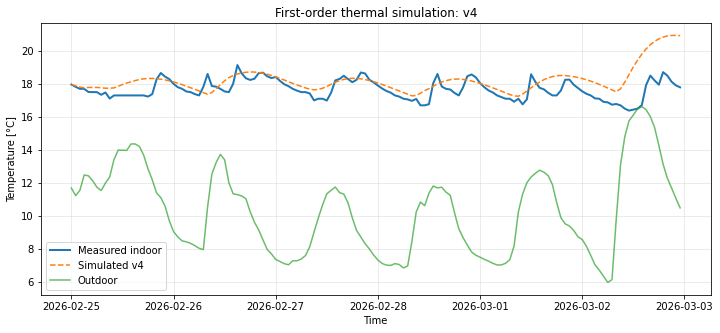

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(df_sim.index, df_sim[column_in], label="Measured indoor", linewidth=2)
plt.plot(df_sim.index, df_sim["Tsim_v4"], label="Simulated v4", linestyle="--")
plt.plot(df_sim.index, df_sim[column_out], label="Outdoor", alpha=0.7)

plt.title("First-order thermal simulation: v4")
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [23]:
mae_v4, rmse_v4 = compute_metrics(df_sim[column_in], df_sim["Tsim_v4"])

print(f"V4 MAE: {mae_v4:.3f} °C | RMSE: {rmse_v4:.3f} °C")

V4 MAE: 0.643 °C | RMSE: 0.945 °C


## v4 Results

The memory-enhanced extension introduces additional model flexibility, but in this case it does not improve predictive accuracy compared to v3.

This suggests that, for the current dataset and time horizon, the simpler dynamic solar formulation already captures most of the relevant thermal behavior.

Therefore, v4 is retained as an exploratory model, but not selected as the preferred simulator.

## Model Comparison

| Model | MAE (°C) | RMSE (°C) | Main feature |
| -------- | ------- | ------- | ------- |
| v1 | 3.666 | 4.170 | basic first-order cooling |
| v2 | 0.566 | 0.696 | constant daytime gain |
| **v3** | **0.439** | **0.614** | **dynamic solar proxy** |
| v4 | 0.643 | 0.945 | memory-enhanced solar proxy |


The four simulator versions can be summarized as follows:

- **v1** captures the basic cooling dynamics, but misses daytime gains
- **v2** improves performance by introducing a constant daytime gain term
- **v3** provides the best overall trade-off by using a dynamic solar proxy
- **v4** explores additional memory effects, but does not improve predictive accuracy further

Overall, **v3** is selected as the preferred working simulator, since it offers the highest explanatory value with limited additional complexity.

## Conclusions

The developed thermal simulator provides a practical first digital twin of the apartment’s thermal behavior.

The results indicate that, under relatively stable operating conditions — that is, in the absence of strong internal gains, intense heating periods, or abrupt temperature disturbances — the model can produce reasonably accurate short-term predictions over horizons of approximately 5–6 days.

This makes the simulator suitable as a first sandbox for:

- thermal behavior exploration
- scenario testing
- future control-oriented experiments

While additional complexity may be needed for longer horizons or more dynamic operating conditions, the current model already offers a practical and interpretable foundation for future thermal control and optimization work.